## Visulize the Temporal patterns

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


In [6]:
## -- Query1  Fraud rate accross all 24 hrs

query1 = """
select hour_of_day,
		count(*) 							as txn_count,
		count(*) filter (where is_fraud)	as fraud_count,
		round(100 * count(*) filter (where is_fraud)
				/ count(*),2)				as fraud_rate_pct,
		round(avg(transaction_amt),2)		as avg_amount
from fraud_dw.fact_transactions
group by hour_of_day
order by hour_of_day;"""

df1 = pd.read_sql(query1,engine)
df1.head(5)

,hour_of_day,txn_count,fraud_count,fraud_rate_pct,avg_amount
0,0,37795,1186,3.0,123.31
1,1,32797,1027,3.0,116.03
2,2,26732,1002,3.0,111.33
3,3,20802,797,3.0,106.60
4,4,14839,770,5.0,102.96


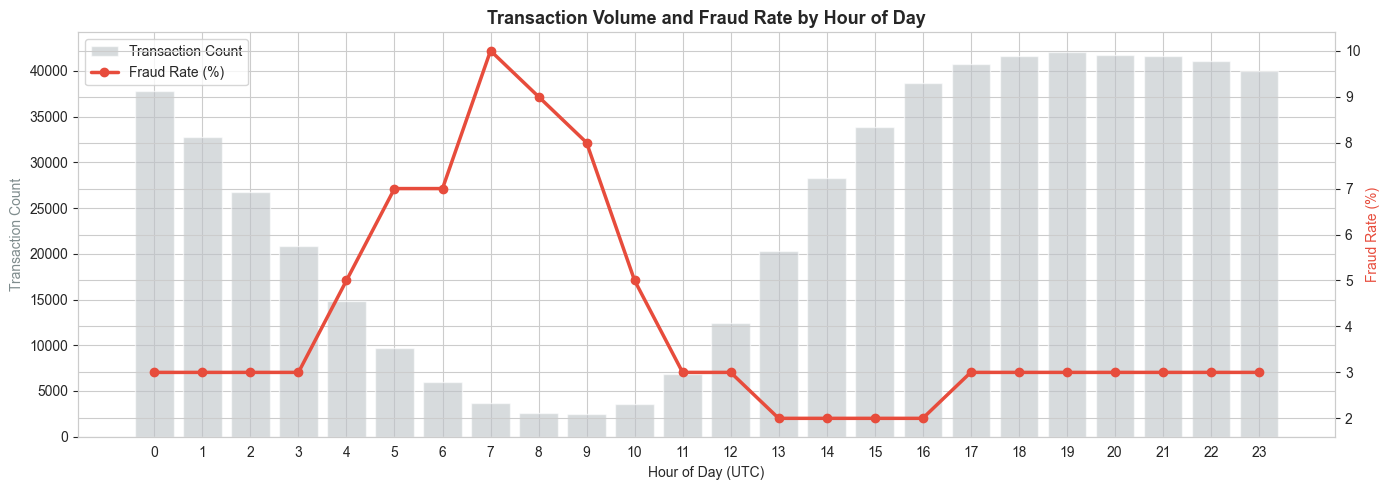

In [11]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# Bar: transaction volume
ax1.bar(df1['hour_of_day'], df1['txn_count'], 
        color='#bdc3c7', alpha=0.6, label='Transaction Count')
ax1.set_xlabel('Hour of Day (UTC)')
ax1.set_ylabel('Transaction Count', color='#7f8c8d')
ax1.set_xticks(range(0, 24))

# Line: fraud rate
ax2.plot(df1['hour_of_day'], df1['fraud_rate_pct'], 
         color='#e74c3c', marker='o', linewidth=2.5, label='Fraud Rate (%)')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')

ax1.set_title('Transaction Volume and Fraud Rate by Hour of Day',
              fontsize=13, fontweight='bold')

# Combine legends
l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc='upper left')

plt.tight_layout()
plt.savefig('visuals/phase2_q1_hour_of_day.png', bbox_inches='tight')
plt.show()

### Insight - 01 

In [9]:
## Query 03 -- Hour x Day fraud rate

query3 = """
select 
		d.day_of_week,
		d.day_name,
		f.hour_of_day,
		count(*) 							as txn_count,
		count(*) filter (where f.is_fraud)	as fraud_count,
		round(100 * count(*) filter (where is_fraud)
				/ nullif(count(*),0),2)				as fraud_rate_pct
from fraud_dw.fact_transactions f
join fraud_dw.dim_date d using (date_id)
group by d.day_of_week, d.day_name, f.hour_of_day
order by d.day_of_week, f.hour_of_day;"""

df3 = pd.read_sql(query3,engine)
df3

,day_of_week,day_name,hour_of_day,txn_count,fraud_count,fraud_rate_pct
0,0,Sunday,0,6185,198,3.0
1,0,Sunday,1,5053,165,3.0
2,0,Sunday,2,3873,167,4.0
3,0,Sunday,3,2843,117,4.0
4,0,Sunday,4,1973,106,5.0
...,...,...,...,...,...,...
163,6,Saturday,19,7265,242,3.0
164,6,Saturday,20,7287,223,3.0
165,6,Saturday,21,7241,228,3.0
166,6,Saturday,22,6853,208,3.0


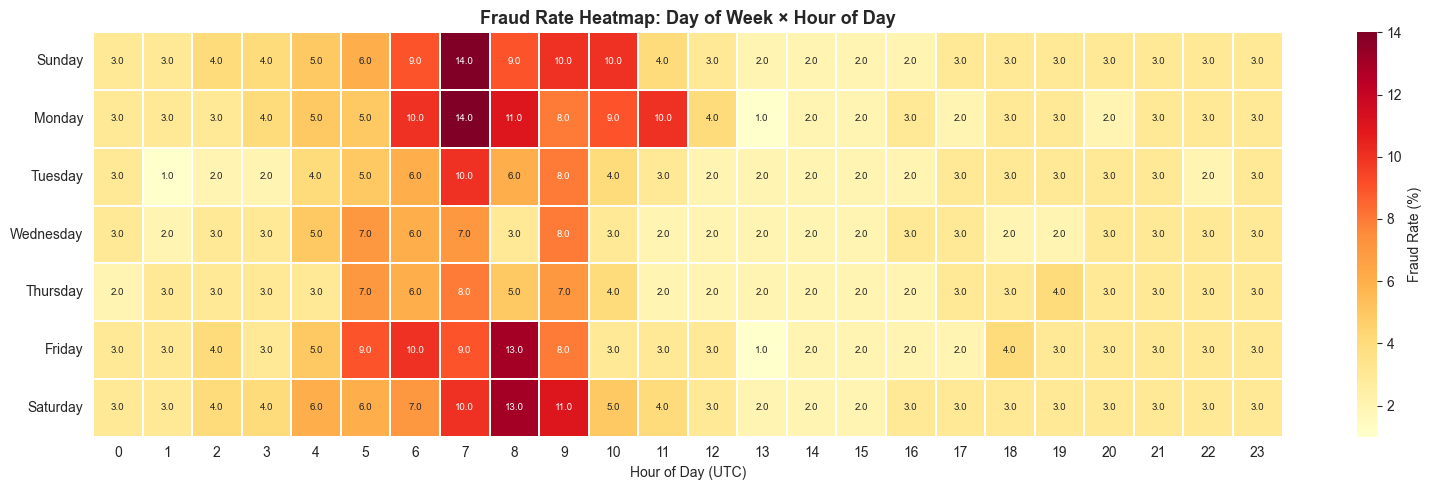

In [ ]:

day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday']

heatmap_data = df3.pivot(index='day_name', 
                         columns='hour_of_day', 
                         values='fraud_rate_pct')
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.1f',
            annot_kws={'size': 7}, cbar_kws={'label': 'Fraud Rate (%)'},
            linewidths=0.3, linecolor='white', ax=ax)
ax.set_title('Fraud Rate Heatmap: Day of Week × Hour of Day',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('visuals/phase2_q3_heatmap.png', bbox_inches='tight')
plt.show()

### Insight 03

In [13]:
## -- Q4. Fraud rate week - over - week

query4 = """
select
		date_trunc('week',f.transaction_dt)::Date	 			as week_start,
		count(*) 												as txn_count,
		count(*) filter (where f.is_fraud) 						as fraud_count,
		round(100 * count(*) filter (where f.is_fraud)
					/ count(*),2)								as fraud_rate_pct,
		round(sum(f.transaction_amt) filter 
					(where f.is_fraud),2)						as fraud_loss_usd
from fraud_dw.fact_transactions f
group by date_trunc('week',f.transaction_dt)::Date
order by week_start;"""

df4 = pd.read_sql(query4,engine)
df4.head()

,week_start,txn_count,fraud_count,fraud_rate_pct,fraud_loss_usd
0,2017-11-27,8852,235,2.0,35696.78
1,2017-12-04,26650,781,2.0,106221.74
2,2017-12-11,29916,718,2.0,99621.99
3,2017-12-18,39066,909,2.0,113526.67
4,2017-12-25,29855,758,2.0,106630.92


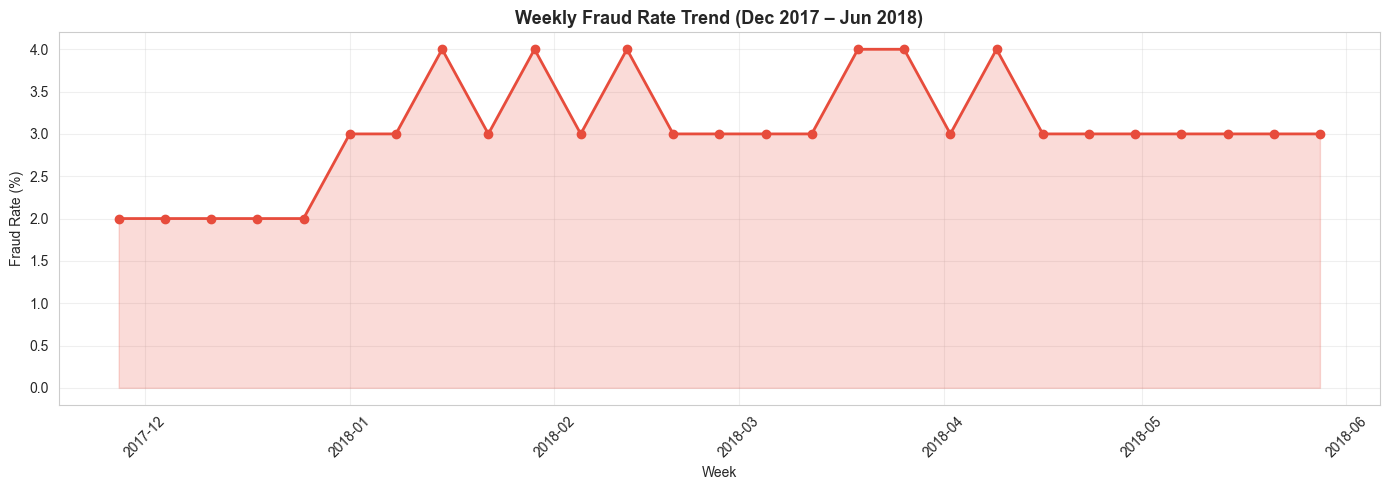

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df4['week_start'], df4['fraud_rate_pct'],
        color='#e74c3c', marker='o', linewidth=2, label='Fraud Rate (%)')
ax.fill_between(df4['week_start'], df4['fraud_rate_pct'], 
                alpha=0.2, color='#e74c3c')

ax.set_xlabel('Week')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Weekly Fraud Rate Trend (Dec 2017 – Jun 2018)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/phase2_q4_weekly_trend.png', bbox_inches='tight')
plt.show()

### Insight 04

In [15]:
## -- Q6. fraud time vary by product

query6 = """

SELECT 
    CASE 
        WHEN hour_of_day BETWEEN 0  AND 5  THEN '00-05 Night'
        WHEN hour_of_day BETWEEN 6  AND 11 THEN '06-11 Morning'
        WHEN hour_of_day BETWEEN 12 AND 17 THEN '12-17 Afternoon'
        WHEN hour_of_day BETWEEN 18 AND 23 THEN '18-23 Evening'
    END                                                 AS time_bucket,
    p.product_category,
    COUNT(*)                                            AS txn_count,
    COUNT(*) FILTER (WHERE f.is_fraud)                  AS fraud_count,
    ROUND(100.0 * COUNT(*) FILTER (WHERE f.is_fraud) 
                / COUNT(*), 3)                          AS fraud_rate_pct
FROM fraud_dw.fact_transactions f
JOIN fraud_dw.dim_product p USING (product_id)
GROUP BY 1, p.product_category
ORDER BY p.product_category, time_bucket;
"""

df6 = pd.read_sql(query6,engine)
df6

,time_bucket,product_category,txn_count,fraud_count,fraud_rate_pct
0,00-05 Night,Card-Not-Present,23880,2738,11.466
1,06-11 Morning,Card-Not-Present,3300,830,25.152
2,12-17 Afternoon,Card-Not-Present,14688,1336,9.096
3,18-23 Evening,Card-Not-Present,26651,3104,11.647
4,00-05 Night,Hotel/Travel,8482,331,3.902
5,06-11 Morning,Hotel/Travel,1470,193,13.129
6,12-17 Afternoon,Hotel/Travel,9973,442,4.432
7,18-23 Evening,Hotel/Travel,13099,608,4.642
8,00-05 Night,Retail,7113,431,6.059
9,06-11 Morning,Retail,1242,101,8.132


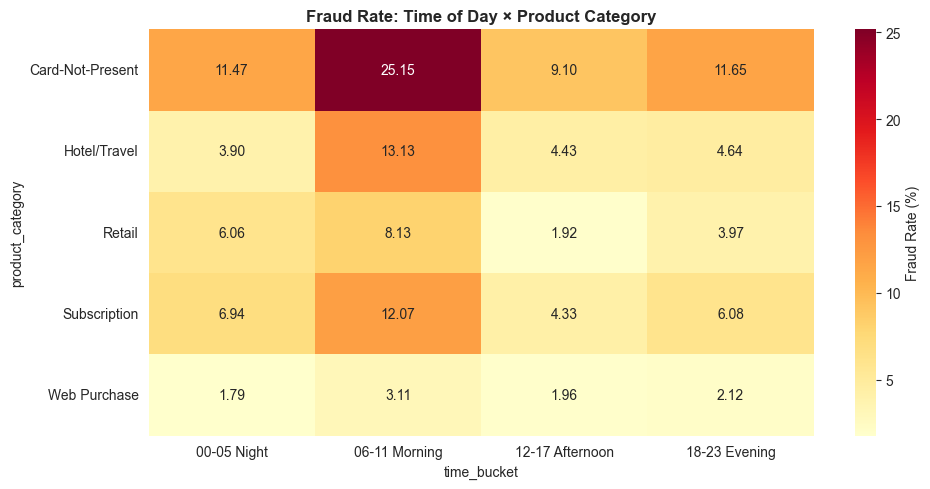

In [16]:
pivot6 = df6.pivot(index='product_category', 
                   columns='time_bucket', 
                   values='fraud_rate_pct')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot6, cmap='YlOrRd', annot=True, fmt='.2f',
            cbar_kws={'label': 'Fraud Rate (%)'}, ax=ax)
ax.set_title('Fraud Rate: Time of Day × Product Category',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase2_q6_time_product.png', bbox_inches='tight')
plt.show()

## Phase 2 Summary

**Key findings:**

1. **Fraud rush hour:** Fraud peaks between 5 am and 9 am UTC.
2. **Day-of-week effect:** Sunday has the highest fraud rate (14 %),Wednesday the lowest.
3. **Hottest cell in the heatmap:** Sunday &  Monday × hour 7 am at 14% fraud.
4. **Weekly trend:** Fraud rate Stabilize with rare peaks across the 6-month window.
5. **Time-product interaction:** Card-not0-present during Morning(6 - 11 am) -  shows the strongest fraud concentration. 
